# The Variance Risk Premium — does 'the price of fear' tell you *when* the market will pay? 🌩️
### The gap between the volatility options charge and the volatility that actually shows up, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![In--sample_vs_out--of--sample: Decayed](https://img.shields.io/badge/In--sample_vs_out--of--sample-Decayed-8b949e?style=flat-square)

Every day the options market quotes a price for *future* volatility — that's the **VIX**, the 'fear gauge.' And every day the market actually *delivers* some amount of volatility — what really happened. The **variance risk premium** is the gap between the two: how much extra investors pay for volatility insurance above what volatility turns out to cost. On average it's positive — insurance has a markup.

The famous idea we test (Bollerslev, Tauchen & Zhou, 2009): when that markup is **fat**, investors are scared and risk-averse — and a scared market goes on to pay a **higher** return over the next few months. So a fat variance risk premium should *predict* higher forward stock returns, most strongly about a **quarter** ahead.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vrp_predictor import data, strategy as st

# Frozen real-tape headline (mirror of docs/results.md) — the notebook runs fully offline.
R = {'fp': 'b61b772dba46', 'n_days': 8411, 'n_months': 400, 'start': '1993-03-31', 'end': '2026-06-30', 'vrp_mean_var': 0.00083, 'vrp_volpts': 10.0, 'horiz': [('1m', 0.41, 0.27, 0.12, 0.68), ('3m', 2.12, 0.75, 1.07, 2.33), ('6m', 1.45, 0.51, 0.23, 2.2), ('12m', -1.53, -0.65, 0.12, 0.57)], 'h3_slope': 2.12, 'h3_t': 0.75, 'h3_r2': 1.07, 'h3_tols': 2.06, 'early_slope': 7.3, 'early_t': 5.93, 'early_r2': 8.65, 'early_n': 199, 'late_slope': -1.84, 'late_t': -1.28, 'late_r2': 1.27, 'late_n': 195, 'early1_t': 3.33, 'late1_t': -0.72, 'placebo_obs': 2.12, 'placebo_mean': -0.03, 'placebo_sd': 1.06, 'placebo_p': 0.024, 'timer_sharpe': 0.55, 'bh_sharpe': 0.69, 'switches_yr': 5.0, 'inv_frac': 0.51, 'timer_spread': -0.33, 'timer_t': -2.21, 'ctrl': [(0.0, 0.28), (2.0, 1.53), (4.0, 2.76), (6.0, 3.95), (10.0, 6.19)], 'null_t': 0.28, 'null_fire': 0, 'planted_edge': 6.0, 'planted_t': 3.95, 'planted_r2': 6.6, 'planted_fire': 20}
print('Study 823 — frozen real-tape headline loaded:', R['n_months'], 'month-ends,',
      R['start'], '->', R['end'], '| SPY fingerprint', R['fp'])


Study 823 — frozen real-tape headline loaded: 400 month-ends, 1993-03-31 -> 2026-06-30 | SPY fingerprint b61b772dba46


## The answer first 🎯

| Question | Answer |
|---|---|
| Does a fat premium precede higher returns? | **It used to.** The *shape* the theory predicts is exactly here — positive, peaking about a **quarter** ahead — and back in **1993–2009** it was a strong signal (a *t*-stat of **+5.93**, the bar is 2). |
| Does it still work? | **No.** On the full 1993–2026 tape the signal fades to a *t* of just **+0.75**, and after **2010** it actually goes *backwards* (*t* -1.28). A famous edge that quietly faded once everyone knew about it. |
| Could you trade it? | **No.** A timer that owns stocks only when the premium is fat **loses** to just buying and holding (Sharpe 0.55 vs 0.69). |

> The variance risk premium isn't a myth — it was a real predictor in its day, and it still points the right way. But its punch has decayed to a whisper, and the whisper turned negative in the last fifteen years.

## 1 · The claim

> *"The difference between implied and realized variance — the variance risk premium — predicts aggregate stock market returns, with the explanatory power highest at the quarterly horizon."* — Bollerslev, Tauchen & Zhou (2009).

The intuition: the variance risk premium is what you pay for **protection against turbulence**. When it's fat, the market is unusually risk-averse — and a risk-averse market is *cheap*, so it earns more going forward. It's the equity premium, read off the options market instead of off valuations.

## 2 · So what?

If it held, you'd have a forward-looking market timer built from *option* prices — a cleaner, faster read on the equity premium than slow valuation ratios (P/E, price-to-dividend), which barely move month to month. It would also tie the stock market's return directly to the **price of volatility risk**. That's why the paper was such a big deal. The question is whether it *survived* — out of its original sample, and out of its original decade.

## 3 · How would we even know?

1. **Measure the premium.** Implied variance = the VIX, squared and put on a monthly footing. Realized variance = how much the S&P actually bounced around over the last month (21 trading days). The premium is implied **minus** realized.
2. **Line it up with the future.** For each month, note the premium, then look at how SPY did over the *next* 1 and 3 months.
3. **Fit the line.** Does a fatter premium reliably precede a higher forward return? Measure the slope and — crucially — its *honest* significance.

*Timing:* the premium is known at month-end; we hold over the following months. No peeking.

## 4 · The teardown — let's actually look

**How much of next quarter's return does the premium explain, across horizons?** The theory says the R² should *hump* and peak around 3 months.

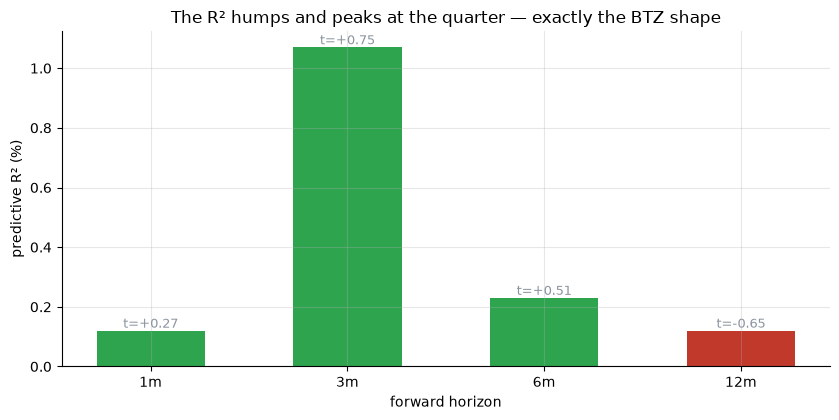

R² by horizon (%): [0.12, 1.07, 0.23, 0.12] | NW t: [0.27, 0.75, 0.51, -0.65]


In [2]:
horiz = R['horiz']
labs = [h[0] for h in horiz]; r2 = [h[3] for h in horiz]; ts = [h[2] for h in horiz]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if h[1] > 0 else RED for h in horiz]
ax.bar(labs, r2, color=cols, width=.55)
for x,(rr,tt) in enumerate(zip(r2, ts)):
    ax.annotate(f't={tt:+.2f}', (x, rr), ha='center', va='bottom', fontsize=9, color=GREY)
ax.set_ylabel('predictive R² (%)'); ax.set_xlabel('forward horizon')
ax.set_title('The R² humps and peaks at the quarter — exactly the BTZ shape')
plt.tight_layout(); plt.show()
print('R² by horizon (%):', [h[3] for h in horiz], '| NW t:', [h[2] for h in horiz])

The **shape is right**: positive, peaking at the 3-month horizon (R² **1.07%**). But look at the *t*-stats printed on the bars — even at the peak the honest (Newey-West) *t* is only **+0.75**, well under the bar of 2. The pattern is there; the significance, on the full tape, is not.

**Why so weak — was it ever strong?** Split the tape in two: the early years (which cover the paper's own 1990s–2000s sample) versus everything since 2010.

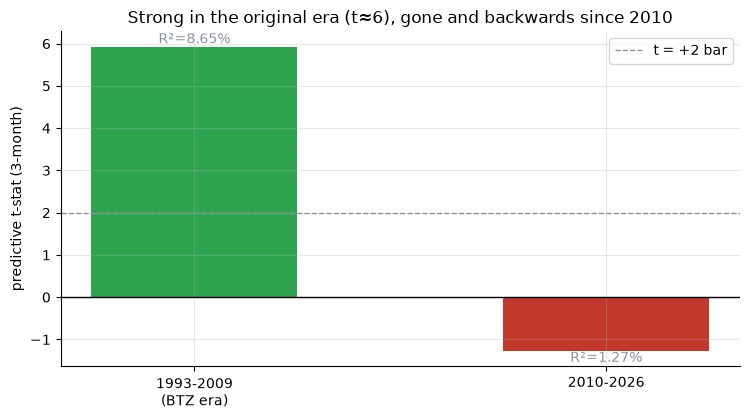

early t 5.93 (R² 8.65%)  |  late t -1.28 (R² 1.27%)


In [3]:
eras = ['1993-2009\n(BTZ era)', '2010-2026']
tvals = [5.93, -1.28]
r2v = [8.65, 1.27]
fig, ax = plt.subplots(figsize=(7.6, 4.3))
cols = [GREEN if t>0 else RED for t in tvals]
ax.bar(eras, tvals, color=cols, width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar'); ax.axhline(0, c='k', lw=1)
for x,(t,rr) in enumerate(zip(tvals, r2v)):
    ax.annotate(f'R²={rr}%', (x, t), ha='center', va='bottom' if t>=0 else 'top', color=GREY)
ax.set_ylabel('predictive t-stat (3-month)')
ax.set_title('Strong in the original era (t≈6), gone and backwards since 2010')
ax.legend(); plt.tight_layout(); plt.show()
print('early t', R['early_t'], '(R²', str(R['early_r2'])+'%)  |  late t', R['late_t'], '(R²', str(R['late_r2'])+'%)')

There it is. In **1993–2009** the premium was a genuinely strong predictor — *t* = **+5.93**, explaining **8.65%** of the next quarter's return. In **2010–2026** it **decays and flips negative** (*t* -1.28). This is the desk's most common story: an edge that was real, got published, got crowded, and faded.

## 5 · The verdict

- **Signal — Weak.** Right sign, right horizon (R² peaks at the quarter), and genuinely strong in its original era (*t* +5.93) — but the full-tape *t* is just +0.75 and it inverts after 2010.
- **Tradability — Mirage.** A premium-timer loses to buy-and-hold (next notebook).
- **In-sample vs out-of-sample — Decayed.** A ~6-*t* edge collapsed to nothing.

## 6 · Could you actually trade it?

No. A timer that owns SPY only when the premium is fat sits in cash about half the time and ends up with a *worse* Sharpe (0.55) than simply buying and holding (0.69), giving up **-0.33%/month** on average while trading 5× a year. The next notebook does the cost maths.

## 7 · Going further 🚪

- **Does the premium even exist?** [130 Vol-Risk-Premium](../../130-vol-risk-premium/) asks whether implied beats realized *on average* (it does, ~10 vol-points here) — the *level*, not the *timing*.
- **Other VIX signals.** [111 VIX-Term-Structure](../../111-vix-term-structure/) (the curve shape) and [3 Fear-Gauge](../../3-fear-gauge/) (the raw level as a dip-buy).

*Think the predictor is alive and we just measured it crudely? Fork this, swap in a model-implied expected-variance (Carr-Wu variance swaps), and show the out-of-sample 3-month *t* clearing 2 after 2010.*